# Interpolation


## Vertiefung


### Übersicht


1. Interpolationspolynom mit NumPy
2. Implementation der Linearen Interpolation entlang mehrerer Punkte
3. Spline-Interpolation mit SciPy
4. Kubische Spline-Interpolation


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Vorbereitung: Daten generieren


Um ein paar Testdaten zu generieren, verwenden wir eine Cosinus-Funktion und berechnen davon an zufälligen Stellen ein paar Werte.

$$ f(x) = a \cdot \cos\left(\frac{2\pi x}{T}\right) $$


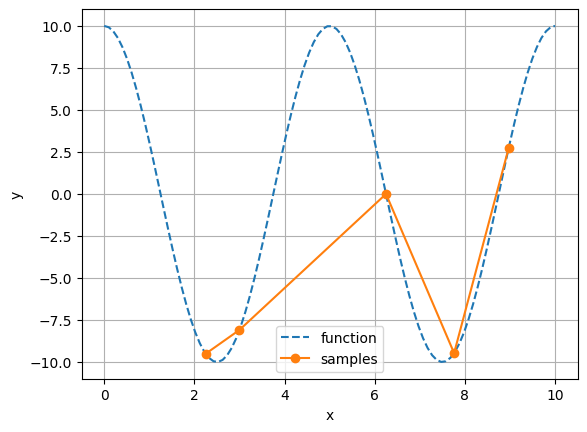

In [2]:
def signal(x, amplitude=10, period=5):
    omega = 2 * np.pi / period
    return amplitude * np.cos(omega * x)


x_signal = np.linspace(0, 10, 100)
y_signal = signal(x_signal)

n_samples = 5
rng = np.random.default_rng(7)
x_data = np.round(np.sort(rng.uniform(low=0, high=10, size=n_samples)), 2)
y_data = np.round(signal(x_data), 2)

plt.plot(x_signal, y_signal, "--", label="function")
plt.plot(x_data, y_data, "o-", label="samples")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

### 1. Interpolationspolynom mit NumPy


Mit der Klasse [`np.polynomial.Polynomial`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html) können Polynom-Funktionen definiert und damit gerechnet werden.

Z.B. das Polynom $p(x) = 1 + 3x + 2x^2$:


In [3]:
p = np.polynomial.Polynomial([1, 3, 2])
p

Polynomial([1., 3., 2.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Das Polynom `p` kann wie eine Funktion verwendet werden, um es an $x$-Werten auszuwerten:


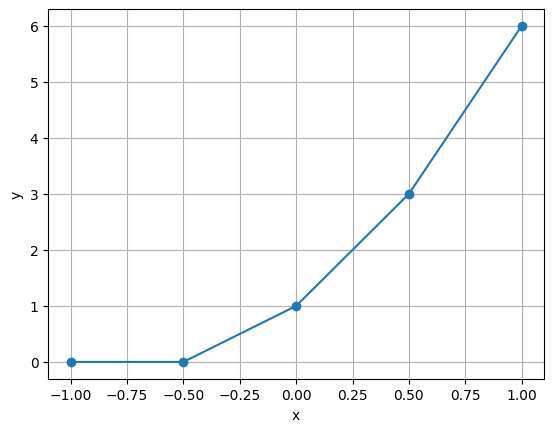

In [4]:
x = np.linspace(-1, 1, 5)
y = p(x)

plt.plot(x, y, "o-")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

Alternativ gibt es die Methode [`Polynomial.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.linspace.html), um direkt einen Linspace zu erzeugen und das Polynom dort auszuwerten.


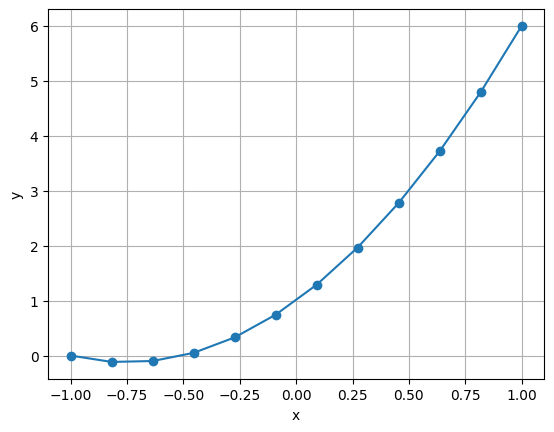

In [5]:
x, y = p.linspace(n=12, domain=(-1, 1))

plt.plot(x, y, "o-")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

Für die Interpolation von Datenpunkten mit einem einzigen Polynom, wird die Methode [`Polynomial.fit`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html) verwendet.

Der Grad des Polynoms muss angegeben werden. Wenn alle Datenpunkte exakt getroffen werden sollen, muss der Grad so gewählt werden, dass es genügend Freiheitsgrade und somit Koeffizienten gibt. Für jeden Datenpunkt gibt es eine Bedingung (Gleichung) und somit braucht es gleich viele Koeffizienten wie Datenpunkte.

$$ \text{Grad} = \text{Anzahl der Datenpunkte} - 1 $$


In [6]:
deg = len(x_data) - 1
poly = np.polynomial.Polynomial.fit(x_data, y_data, deg)
poly

Polynomial([  3.19496996, -10.27737856, -38.38206844,  16.39737856,
        31.79709848], domain=[2.25, 8.97], window=[-1.,  1.], symbol='x')

Mit der Eigenschaft `Polynomial.coef` können die (ausmultiplizierten) Koeffizienten $a_k$ bzgl. der Potenzen $x^k$ ausgegeben werden.

In [7]:
print(poly.coef)
np.polynomial.Polynomial(poly.coef)

[  3.19496996 -10.27737856 -38.38206844  16.39737856  31.79709848]


Polynomial([  3.19496996, -10.27737856, -38.38206844,  16.39737856,
        31.79709848], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

**Bemerkung:** Es kann auch ein Polynom tieferen Grades an die Daten gefittet werden. Dann kann es aber nicht mehr exakt durch alle Datenpunkte gehen. In diesem Fall wird die Methode der kleinsten Quadrate (_engl. least squares fit_) verwendet und das Resultat ist nicht mehr eine Interpolation sondern eine Regression.


In [8]:
poly3 = np.polynomial.Polynomial.fit(x_data, y_data, deg=3)
poly3

Polynomial([-2.73012492, -7.33687495, -2.48471424, 13.61417005], domain=[2.25, 8.97], window=[-1.,  1.], symbol='x')

**Darstellung**


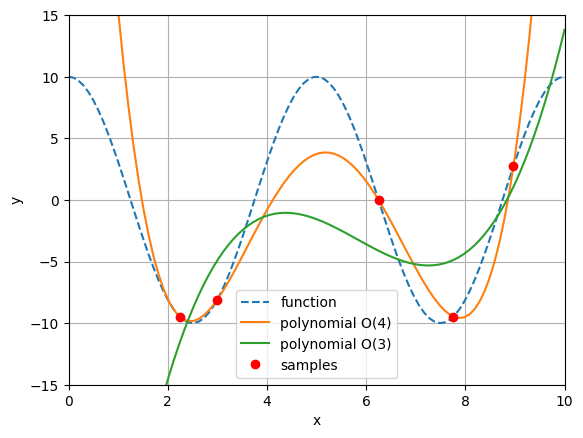

In [9]:
y_poly = poly(x_signal)
y_poly3 = poly3(x_signal)

plt.plot(x_signal, y_signal, "--", label="function")
plt.plot(x_signal, y_poly, label=f"polynomial O({deg})")
plt.plot(x_signal, y_poly3, label="polynomial O(3)")
plt.plot(x_data, y_data, "or", label="samples")
plt.xlim(0, 10)
plt.ylim(-15, 15)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

### 2. Implementation der Linearen Interpolation entlang mehrerer Punkte


Die lineare Interpolation zwischen zwei Datenpunkten $(x_1, y_1)$ und $(x_2, y_2)$ ist eine Gerade, die durch die beiden Punkte geht. Die Steigung $m$ entspricht dem Differenzenquotienten und dann wird die Gerade so verschoben, dass sie durch den ersten Punkt geht (und somit auch durch den zweiten Punkt).

\begin{align*}
m &= \frac{y_2 - y_1}{x_2 - x_1} \\
y &= y_1 + m \cdot (x - x_1)
\end{align*}

Haben wir mehrere Datenpunkte, $(x_i,y_i)$ mit $i=0,1,\ldots,n-1$, so können wir jeweils zwischen zwei benachbarten Stützstellen linear interpolieren.

Schritte

1. Index $i$ und $i+1$ der benachbarten Stützstellen suchen: [`np.searchsorted`](https://numpy.org/doc/stable/reference/generated/numpy.searchsorted.html)
2. Lineare Interpolation mithilfe der benachbarten Datenpunkte konstruieren

\begin{align*}
m_i &= \frac{y_{i+1} - y_{i}}{x_{i+1} - x_{i}} \\
y &= y_i + m_i \cdot (x - x_i)
\end{align*}


In [10]:
x = 5
i = np.searchsorted(x_data, x) - 1
mi = (y_data[i + 1] - y_data[i]) / (x_data[i + 1] - x_data[i])
y = y_data[i] + mi * (x - x_data[i])
y

np.float64(-3.111538461538461)

Nun etwas allgemeiner mithilfe von [`np.searchsorted`](https://numpy.org/doc/stable/reference/generated/numpy.searchsorted.html) und [`np.diff`](https://numpy.org/doc/stable/reference/generated/numpy.diff.html):


In [11]:
def lin_interp(x_data, y_data, x):
    i = np.searchsorted(x_data, x) - 1
    i = np.where(i < 0, 0, i)
    m = np.diff(y_data) / np.diff(x_data)
    return y_data[i] + m[i] * (x - x_data[i])


lin_interp(x_data, y_data, x)

np.float64(-3.111538461538461)

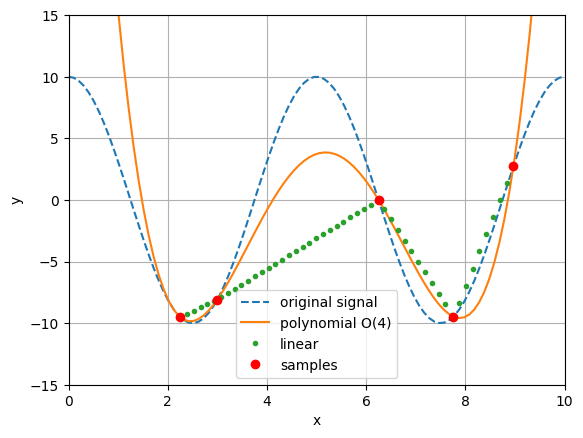

In [12]:
x_interp = np.linspace(x_data.min(), x_data.max())
y_linear = lin_interp(x_data, y_data, x_interp)

plt.plot(x_signal, y_signal, "--", label="original signal")
plt.plot(x_signal, y_poly, "-", label=f"polynomial O({deg})")
plt.plot(x_interp, y_linear, ".", label="linear")
plt.plot(x_data, y_data, "ro", label="samples")
plt.xlim(0, 10)
plt.ylim(-15, 15)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

### 3. Spline-Interpolation mit SciPy


-   Übersicht zu Interpolation mit SciPy [`scipy.interpolate`](https://docs.scipy.org/doc/scipy/reference/interpolate.html).
-   Die Funktion [`scipy.interpolate.make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html) ist der wesentliche Einstiegspunkt.
    -   Die Option `k` bestimmt den Grad des Polynoms, das für die Interpolation verwendet wird. Standardmässig wird mit `k=3` ein kubisches Spline berechnet. `k=1`entspricht einer linearen Interpolation, `k=2` ist ein quadratischer Spline.
    -   Die Option `bc_type` bestimmt die Randbedingungen. Meist liefert `bc_type="natural"` bessere Resultate als die Standardeinstellung `bc_type="not-a-knot"`. Lies dazu die Dokumentation.
-   Viele Beispiele, die man online findet, verwenden die Funktion [`scipy.interpolate.interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html). Diese Funktion funktioniert sehr ähnlich, bietet aber nicht alle Möglichkeiten von [`make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html) und wird in der Dokumentation als veraltet (legacy) bezeichnet.
-   Das Sub-Package [`scipy.interpolate`](https://docs.scipy.org/doc/scipy/reference/interpolate.html) bietet auch Möglichkeiten zur Interpolation mehrdimensionaler Daten.
-   Weitere Informationen zu Splines findet man hier
    -   ["Spline-Interpolation", Wikipedia](https://de.wikipedia.org/wiki/Spline-Interpolation)
    -   ["Cubic Spline Interpolation", Wikiversity](https://en.wikiversity.org/wiki/Cubic_Spline_Interpolation).


In [13]:
from scipy.interpolate import make_interp_spline

k = 3
spline_clamped = make_interp_spline(x_data, y_data, k, bc_type="clamped")
spline_natural = make_interp_spline(x_data, y_data, k, bc_type="natural")

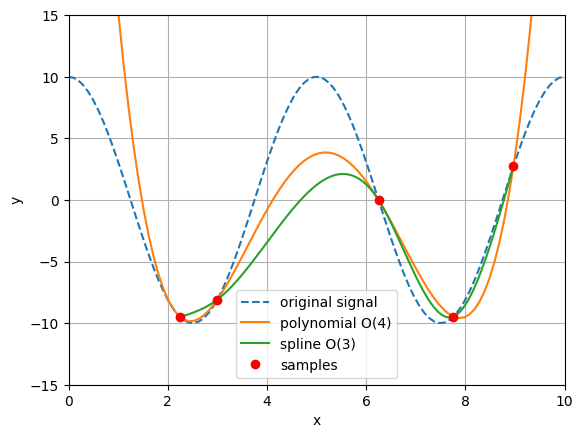

In [14]:
x_interp = np.linspace(x_data.min(), x_data.max(), 250)
y_spl = spline_natural(x_interp)

plt.plot(x_signal, y_signal, "--", label="original signal")
plt.plot(x_signal, y_poly, "-", label=f"polynomial O({deg})")
plt.plot(x_interp, y_spl, label=f"spline O({k})")
plt.plot(x_data, y_data, "ro", label="samples")
plt.xlim(0, 10)
plt.ylim(-15, 15)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

### 4. Kubische Spline-Interpolation


Bei der kubischen Spline-Interpolation werden je zwei benachbarte Datenpunkte $(x_j,y_j)$ und $(x_{j+1},y_{j+1})$ durch ein kubisches Polynom verbunden:

$$
    s_j(x) = a_j + b_j(x-x_j) + c_j(x-x_j)^2 + d_j(x-x_j)^3
$$

Dabei wird gefordert, dass

-   die Polynome durch die Stützstellen gehen:
    
    $s_j(x_j) = y_j$ und $s_j(x_{j+1}) = y_{j+1}$

-   benachbarte Polynome an den Stützstellen die gleichen Ableitungen haben:

    $s_j'(x_{j+1}) = s_{j+1}'(x_{j+1})$ und $s_j''(x_{j+1}) = s_{j+1}''(x_{j+1})$

-   die Polynome an den Randpunkten keiner "externen Kraft" ausgesetzt sind (natürliche Randbedingungen):

    $s_0''(x_0) = s_{n-1}''(x_n) = 0$

#### Beispiel: Drei Punkte, Zwei Intervalle


Gesucht sind die beiden Spline-Polynome durch die folgenden drei Punkte:

\begin{align*}
(x_0, y_0) &= (0, 1) \\
(x_1, y_1) &= (1, 2) \\
(x_2, y_2) &= (2, 8)
\end{align*}

Da es 3 Punkte sind, gibt es 2 Intervalle und somit 2 Polynome, deren Koeffizienten bestimmt werden müssen.

Plan:

-   Wir schreiben die beiden Polynome auf ($x_0=0$ und $x_1=1$ einsetzen!).
-   Wir berechne deren erste und zweite Ableitungen.
-   Wir Schreiben die Bedingungen auf, welche die Polynome und die Ableitungen erfüllen müssen.
-   Wir bestimmen daraus ein Gleichungssystem für die Koeffizienten und lösen es.
-   Am einfachsten geht dies in der Matrixschreibweise $A\cdot \vec k = \vec c \ \Rightarrow \ \vec k = A^{-1}\cdot \vec c$, wobei $\vec k = (a_0, b_0, c_0, d_0, a_1, b_1, c_1, d_1)$ der Vektor der gesuchten Koeffizienten ist. Das Inverse kann mit NumPy oder Wolfram|Alpha berechnet werden.
-   Wir stellen die linear verbundenen Punkte und die kubischen Splines grafisch dar.


#### Lösung


Die gesuchten Polynome sind:

\begin{align*}
s_0(x) &= a_0 + b_0 x + c_0 x^2 + d_0 x^3 \\
s_1(x) &= a_1 + b_1 (x-1) + c_1 (x-1)^2 + d_1 (x-1)^3
\end{align*}

Ableitungen:

\begin{align*}
s_0'(x) &= b_0 + 2c_0x + 3d_0x^2 \\
s_0''(x) &= 2c_0 + 6d_0x \\
s_1'(x) &= b_1 + 2c_1(x-1) + 3d_1(x-1)^2 \\
s_1''(x) &= 2c_1 + 6d_1(x-1)
\end{align*}

Bedingungen durch Funktionswerte:

\begin{align*}
s_0(x_0) &= a_0 = 1 \\
s_0(x_1) &= a_0 + b_0 + c_0 + d_0 = 2 \\
s_1(x_1) &= a_1 = 2 \\
s_1(x_2) &= a_1 + b_1 + c_1 + d_1 = 8
\end{align*}

Ableitungsbedingungen an den inneren Punkten:

\begin{align*}
s_0'(x_1) &= s_1'(x_1) \quad\Rightarrow\quad& b_0 + 2c_0 + 3d_0 &= b_1 \\
s_0''(x_1) &= s_1''(x_1) \quad\Rightarrow\quad& 2c_0 + 6d_0 &= 2c_1 \\
\end{align*}

Natürliche Randbedingungen:

\begin{align*}
s_0''(x_0) &= 2c_0 = 0 \\
s_1''(x_2) &= 2c_1 + 6d_1 = 0
\end{align*}

Zusammen ergibt sich das Gleichungssystem:

$$
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
1 & 1 & 1 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 1 & 1 & 1 \\
0 & 1 & 2 & 3 & 0 & -1 & 0 & 0 \\
0 & 0 & 2 & 6 & 0 & 0 & -2 & 0 \\
0 & 0 & 2 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 2 & 6
\end{pmatrix}
\cdot
\begin{pmatrix}
a_0 \\ b_0 \\ c_0 \\ d_0 \\ a_1 \\ b_1 \\ c_1 \\ d_1
\end{pmatrix}
=
\begin{pmatrix}
1 \\ 2 \\ 2 \\ 8 \\ 0 \\ 0 \\ 0 \\ 0
\end{pmatrix}
$$


In [15]:
A = np.array(
    [
        [1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [0, 1, 2, 3, 0, -1, 0, 0],
        [0, 0, 2, 6, 0, 0, -2, 0],
        [0, 0, 2, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 2, 6],
    ]
)
c = np.array([1, 2, 2, 8, 0, 0, 0, 0])
k = np.linalg.inv(A) @ c
k

array([ 1.  , -0.25,  0.  ,  1.25,  2.  ,  3.5 ,  3.75, -1.25])

In [16]:
s0 = np.polynomial.Polynomial(k[:4])
s1 = np.polynomial.Polynomial(k[4:])


def my_spline(x):
    return np.where(x < 1, s0(x), s1(x - 1))

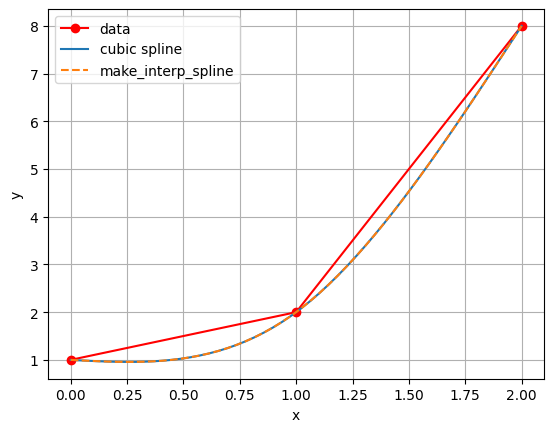

In [17]:
x_data = np.arange(3)
y_data = np.array([1, 2, 8])
x = np.linspace(0, 2)

# analytisch berechneter Spline
y_spline = my_spline(x)

# zum Vergleich Spline mit scipy
spline_func = make_interp_spline(x_data, y_data, bc_type="natural")
y_spline_2 = spline_func(x)

plt.plot(x_data, y_data, "ro-", label="data")
plt.plot(x, y_spline, label="cubic spline")
plt.plot(x, y_spline_2, "--", label="make_interp_spline")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()